In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
!pip install neurokit2
import neurokit2 as nk
import warnings
warnings.filterwarnings('ignore')
import joblib

from scipy.stats import skew, kurtosis
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.metrics import precision_recall_fscore_support
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 9.4 MB/s eta 0:00:00


In [2]:
df = pd.read_csv("/content/pain_dataset_200P_4hz.csv")

**EDA**

In [3]:
df.head()

,person_ID,acc_x,acc_y,acc_z,eda,bvp,hr,temp,pain_scale
0,P001,0.2751,-0.0464,0.3049,0.7395,99.24,67.6,33.94,5
1,P001,0.2428,-0.1161,0.3641,0.7793,103.24,68.3,33.95,5
2,P001,0.0146,-0.1479,0.6552,0.8581,103.08,68.1,33.91,5
3,P001,-0.0806,-0.2144,0.6631,0.8881,104.12,66.6,33.94,5
4,P001,-0.0808,-0.1754,0.5448,0.7786,107.05,66.8,33.95,5


In [4]:
df.isnull().sum()

,0
person_ID,0
acc_x,0
acc_y,0
acc_z,0
eda,0
bvp,0
hr,0
temp,0
pain_scale,0


In [5]:
df.tail()

,person_ID,acc_x,acc_y,acc_z,eda,bvp,hr,temp,pain_scale
95995,P200,0.3618,0.0199,0.1452,5.2451,124.71,104.4,36.09,7
95996,P200,0.2842,-0.1367,0.0158,5.3054,125.71,103.4,36.09,7
95997,P200,0.3005,-0.1288,-0.1729,5.2345,125.07,103.3,36.13,7
95998,P200,0.2964,-0.1015,-0.2274,5.2046,126.12,102.7,36.19,7
95999,P200,0.2739,-0.1166,-0.3405,5.2938,128.74,103.1,36.22,7


In [6]:
df.describe()

,acc_x,acc_y,acc_z,eda,bvp,hr,temp,pain_scale
count,96000.000000,96000.000000,96000.000000,96000.000000,96000.000000,96000.000000,96000.000000,96000.00000
mean,0.000359,-0.005374,0.005558,2.890202,86.924307,79.270666,34.514430,4.53500
std,0.274042,0.274731,0.274240,2.151289,26.516553,13.785112,1.731756,2.13748
min,-1.249800,-1.025200,-1.211600,0.050000,40.000000,50.000000,30.250000,1.00000
25%,-0.182800,-0.190400,-0.178500,0.991100,64.290000,69.100000,33.320000,3.00000
50%,0.000300,-0.005150,0.003400,2.674100,89.130000,79.200000,34.560000,4.00000
75%,0.184300,0.179300,0.187600,4.464400,109.370000,89.725000,35.830000,6.00000
max,1.138500,1.171900,1.103000,9.862200,130.000000,110.000000,38.000000,8.00000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96000 entries, 0 to 95999
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   person_ID   96000 non-null  object 
 1   acc_x       96000 non-null  float64
 2   acc_y       96000 non-null  float64
 3   acc_z       96000 non-null  float64
 4   eda         96000 non-null  float64
 5   bvp         96000 non-null  float64
 6   hr          96000 non-null  float64
 7   temp        96000 non-null  float64
 8   pain_scale  96000 non-null  int64  
dtypes: float64(7), int64(1), object(1)
memory usage: 6.6+ MB


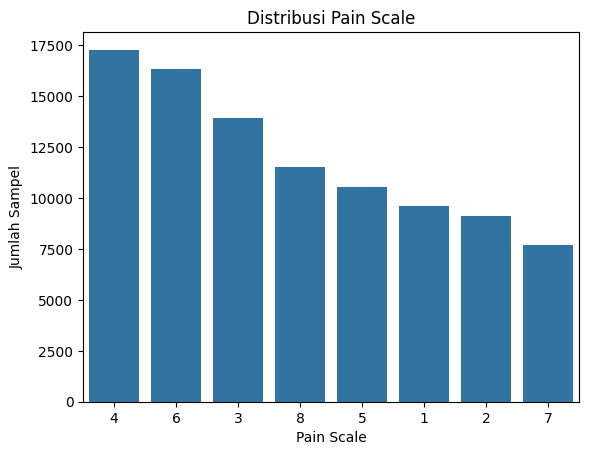

In [8]:
sns.countplot(data=df, x='pain_scale', order=df['pain_scale'].value_counts().index)
plt.title("Distribusi Pain Scale")
plt.xlabel("Pain Scale")
plt.ylabel("Jumlah Sampel")
plt.show()

In [9]:
print(df['pain_scale'].value_counts().sort_index())

pain_scale
1     9600
2     9120
3    13920
4    17280
5    10560
6    16320
7     7680
8    11520
Name: count, dtype: int64


Insight dari count plot:
1. Ada 2 skala yang mendominasi yaitu skala 4 dan 6
2. Ratio Max/Min skala: 17280/7680 = 2.25

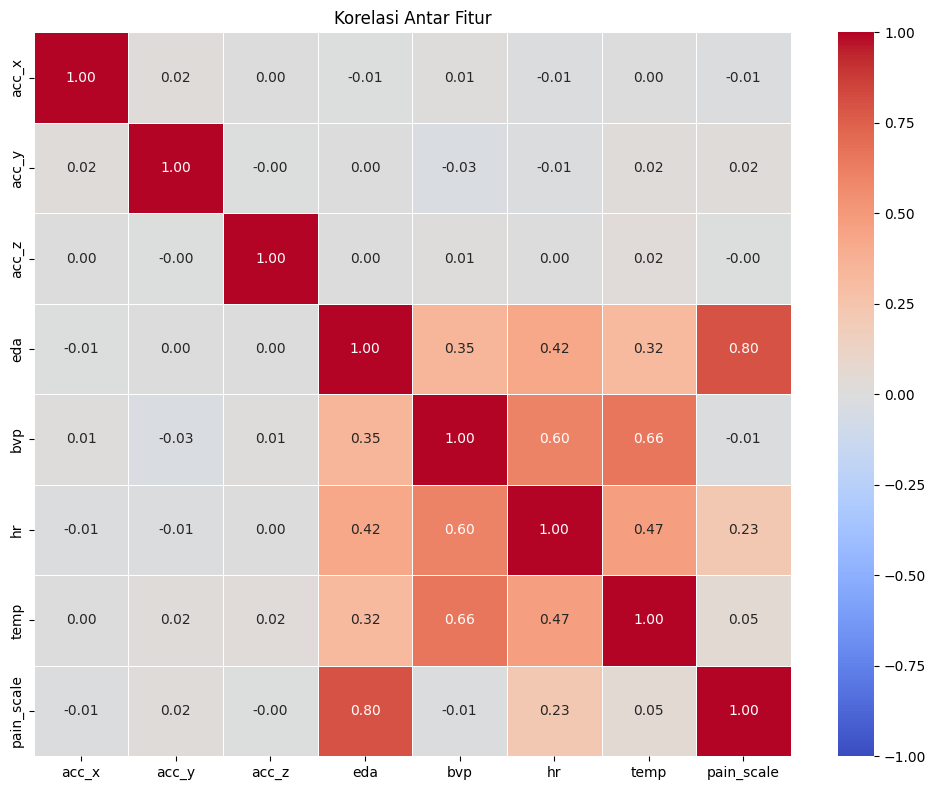

In [10]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5
)
plt.title("Korelasi Antar Fitur")
plt.tight_layout()
plt.show()

**PreProcessing**

Insight dari corr map ini:
1. eda punya korelasi kuat positif dengan pain_scale
2. bvp punya korelasi kuat positif dengan temp dan hr
3. eda juga punya korelasi kuat positif dengan hr


In [11]:
def sort_pain_level(scale):
  if scale in [1, 2, 3]:
    return 'Low'
  elif scale in [4, 5]:
    return 'Medium'
  else:
    return 'High'

df['pain_level'] = df['pain_scale'].apply(sort_pain_level)
print(df['pain_level'].value_counts())

pain_level
High      35520
Low       32640
Medium    27840
Name: count, dtype: int64


In [12]:
df.head()

,person_ID,acc_x,acc_y,acc_z,eda,bvp,hr,temp,pain_scale,pain_level
0,P001,0.2751,-0.0464,0.3049,0.7395,99.24,67.6,33.94,5,Medium
1,P001,0.2428,-0.1161,0.3641,0.7793,103.24,68.3,33.95,5,Medium
2,P001,0.0146,-0.1479,0.6552,0.8581,103.08,68.1,33.91,5,Medium
3,P001,-0.0806,-0.2144,0.6631,0.8881,104.12,66.6,33.94,5,Medium
4,P001,-0.0808,-0.1754,0.5448,0.7786,107.05,66.8,33.95,5,Medium


In [13]:
# Encode
target_mapping = {
    'Low': 0,
    'Medium': 1,
    'High': 2
}

df['target'] = df['pain_level'].map(target_mapping)
X = df.drop(columns=['person_ID', 'pain_scale', 'pain_level', 'target'])
y = df['target']

print("Fitur yang akan digunakan:", X.columns.tolist())
print(y.value_counts())

Fitur yang akan digunakan: ['acc_x', 'acc_y', 'acc_z', 'eda', 'bvp', 'hr', 'temp']
target
2    35520
0    32640
1    27840
Name: count, dtype: int64


In [14]:
df.head()

,person_ID,acc_x,acc_y,acc_z,eda,bvp,hr,temp,pain_scale,pain_level,target
0,P001,0.2751,-0.0464,0.3049,0.7395,99.24,67.6,33.94,5,Medium,1
1,P001,0.2428,-0.1161,0.3641,0.7793,103.24,68.3,33.95,5,Medium,1
2,P001,0.0146,-0.1479,0.6552,0.8581,103.08,68.1,33.91,5,Medium,1
3,P001,-0.0806,-0.2144,0.6631,0.8881,104.12,66.6,33.94,5,Medium,1
4,P001,-0.0808,-0.1754,0.5448,0.7786,107.05,66.8,33.95,5,Medium,1


In [15]:
subject_baselines = df.groupby('person_ID')[['hr', 'eda']].agg(['mean', 'std']).head(5)
print(subject_baselines)

                  hr                  eda          
                mean        std      mean       std
person_ID                                          
P001       73.665000  13.121056  1.944492  1.141665
P002       76.686458   8.161852  0.152602  0.177569
P003       70.973750   9.236558  2.279961  0.765150
P004       84.285833  12.041030  1.072497  0.695904
P005       67.188125   7.213416  1.811493  1.106484


In [16]:
hr_response = df.groupby(['person_ID', 'pain_level'])['hr'].mean().unstack()[['Low', 'High']].head(5)
print(hr_response)

pain_level        Low  High
person_ID                  
P001              NaN   NaN
P002        76.686458   NaN
P003              NaN   NaN
P004              NaN   NaN
P005              NaN   NaN


In [17]:
print(df.groupby('person_ID')['pain_level'].unique().head(5))

person_ID
P001    [Medium]
P002       [Low]
P003    [Medium]
P004    [Medium]
P005    [Medium]
Name: pain_level, dtype: object


In [18]:
# Ngurutin data berdasarkan person_ID
df = df.sort_values(by=['person_ID']).reset_index(drop=True)

In [19]:
# Mengubah koordinat 3D menjadi total intensitas pergerakan fisik
df['acc_mag'] = np.sqrt(df['acc_x']**2 + df['acc_y']**2 + df['acc_z']**2)

In [20]:
# NeuroKit2 akan membedakan SCL (Tonic - level stres dasar) dan SCR (Phasic - lonjakan nyeri akut)
eda_phasic_list = []
eda_tonic_list = []

for pid, group in df.groupby('person_ID'):
  signals, info = nk.eda_process(group['eda'], sampling_rate=4)
  eda_phasic_list.append(signals['EDA_Phasic'].values)
  eda_tonic_list.append(signals['EDA_Tonic'].values)

df['eda_phasic'] = np.concatenate(eda_phasic_list)
df['eda_tonic'] = np.concatenate(eda_tonic_list)

In [21]:
df.head()

,person_ID,acc_x,acc_y,acc_z,eda,bvp,hr,temp,pain_scale,pain_level,target,acc_mag,eda_phasic,eda_tonic
0,P001,0.2751,-0.0464,0.3049,0.7395,99.24,67.6,33.94,5,Medium,1,0.413276,0.016731,0.722769
1,P001,-0.1455,0.2560,0.1652,1.9544,80.11,56.3,33.45,5,Medium,1,0.337635,1.184838,0.769562
2,P001,-0.1529,0.0680,0.1612,1.8851,84.78,56.6,33.48,5,Medium,1,0.232353,1.068891,0.816209
3,P001,-0.2095,0.1784,-0.0413,1.9072,85.08,59.8,33.54,5,Medium,1,0.278249,1.044759,0.862441
4,P001,-0.2774,0.0602,0.1727,1.8409,83.04,59.3,33.54,5,Medium,1,0.332265,0.932870,0.908030


Feature Engineering:
1. Menambahkan fitur eda_phasic: menangkap sympathetic spikes (lonjakan sistem saraf simpatis) yang terjadi dalam hitungan milidetik saat tubuh merespon rasa sakit.
2. Menambahkan fitur eda_phasic_roll_skew: Mengukur kemiringan distribusi data dalam 5 detik terakhir. Jika nilainya positif tinggi, artinya baru saja terjadi lonjakan ekstrem tiba-tiba (ada hantaman rasa nyeri baru).
3. Menambahkan fitur acc_mag: Menghilangkan bias arah gerakan tangan (apakah tangan bergerak ke atas atau ke samping tidak penting, yang penting adalah total energi gerakannya).

In [22]:
window_size = 20

df['hr_roll_mean'] = df.groupby('person_ID')['hr'].transform(lambda x: x.rolling(window_size, min_periods=1).mean())
df['hr_roll_std']  = df.groupby('person_ID')['hr'].transform(lambda x: x.rolling(window_size, min_periods=1).std().fillna(0))

df['eda_phasic_roll_mean'] = df.groupby('person_ID')['eda_phasic'].transform(lambda x: x.rolling(window_size, min_periods=1).mean())
df['eda_phasic_roll_skew'] = df.groupby('person_ID')['eda_phasic'].transform(lambda x: x.rolling(window_size, min_periods=1).apply(lambda s: skew(s) if len(s) > 2 else 0, raw=True))

In [23]:
features_to_keep = ['eda_tonic', 'eda_phasic', 'hr_roll_mean', 'hr_roll_std', 'eda_phasic_roll_mean', 'eda_phasic_roll_skew', 'acc_mag', 'bvp', 'temp']
print(features_to_keep)

['eda_tonic', 'eda_phasic', 'hr_roll_mean', 'hr_roll_std', 'eda_phasic_roll_mean', 'eda_phasic_roll_skew', 'acc_mag', 'bvp', 'temp']


In [24]:
X = df[features_to_keep]
y = df['pain_level'].map({'Low': 0, 'Medium': 1, 'High': 2})
groups = df['person_ID']

**Modeling**

In [25]:
gss = GroupShuffleSplit(n_splits=1, train_size=0.8, random_state=42)

In [26]:
train_idx, test_idx = next(gss.split(X, y, groups=groups))

In [27]:
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
groups_train, groups_test = groups.iloc[train_idx], groups.iloc[test_idx]

In [28]:
print({len(X_train)})
print({len(X_test)})

print({groups_train.nunique()})
print({groups_test.nunique()})

print(y_test.value_counts())

{76800}
{19200}
{160}
{40}
pain_level
2    9120
0    7680
1    2400
Name: count, dtype: int64


In [29]:
# TEMPORAL FEATURE ENGINEERING

def get_rolling_skew_exp(x, w):
    return x.rolling(w, min_periods=1).apply(lambda s: skew(s) if len(s) > 2 else 0, raw=True)

windows_to_try = [10, 40]

for w in windows_to_try:
    print(f"\n{'='*50}")
    print(f"EKSPERIMEN WINDOW SIZE: {w} Baris ({w/4} Detik)")
    print(f"{'='*50}")

    X_exp = X.copy()
    X_exp['hr_roll_mean'] = df.groupby('person_ID')['hr'].transform(lambda x: x.rolling(w, min_periods=1).mean())
    X_exp['hr_roll_std']  = df.groupby('person_ID')['hr'].transform(lambda x: x.rolling(w, min_periods=1).std().fillna(0))
    X_exp['eda_phasic_roll_mean'] = df.groupby('person_ID')['eda_phasic'].transform(lambda x: x.rolling(w, min_periods=1).mean())
    X_exp['eda_phasic_roll_skew'] = df.groupby('person_ID')['eda_phasic'].transform(lambda x: get_rolling_skew_exp(x, w))

X_train_exp = X_exp.iloc[train_idx]
X_test_exp  = X_exp.iloc[test_idx]

rf_exp = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
rf_exp.fit(X_train_exp, y_train)


EKSPERIMEN WINDOW SIZE: 10 Baris (2.5 Detik)

EKSPERIMEN WINDOW SIZE: 40 Baris (10.0 Detik)


RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)

In [30]:
y_pred_exp = rf_exp.predict(X_test_exp)
print(classification_report(y_test, y_pred_exp, target_names=['Low', 'Medium', 'High']))

              precision    recall  f1-score   support

         Low       0.92      0.77      0.84      7680
      Medium       0.30      0.42      0.35      2400
        High       0.91      0.94      0.92      9120

    accuracy                           0.80     19200
   macro avg       0.71      0.71      0.70     19200
weighted avg       0.84      0.80      0.82     19200



**Hyperparameter tuning**

In [31]:
balanced_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    class_weight={0: 1, 1: 1.5, 2: 1},
    random_state=42,
    n_jobs=-1
)

In [32]:
balanced_model.fit(X_train, y_train)

RandomForestClassifier(class_weight={0: 1, 1: 1.5, 2: 1}, max_depth=12,
                       min_samples_leaf=5, min_samples_split=10,
                       n_estimators=300, n_jobs=-1, random_state=42)

In [33]:
y_pred_balanced = balanced_model.predict(X_test)

In [34]:
print(classification_report(y_test, y_pred_balanced, target_names=['Low', 'Medium', 'High']))

              precision    recall  f1-score   support

         Low       0.92      0.70      0.80      7680
      Medium       0.30      0.58      0.39      2400
        High       0.94      0.89      0.91      9120

    accuracy                           0.78     19200
   macro avg       0.72      0.72      0.70     19200
weighted avg       0.85      0.78      0.80     19200



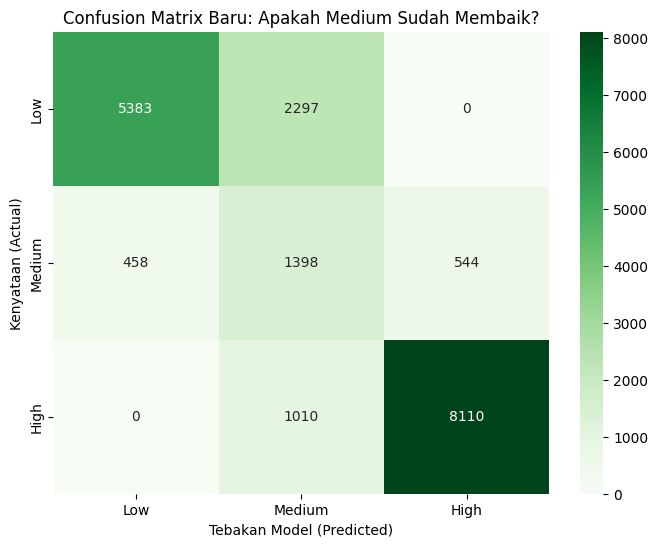

In [35]:
plt.figure(figsize=(8, 6))
cm_balanced = confusion_matrix(y_test, y_pred_balanced)
sns.heatmap(cm_balanced, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Low', 'Medium', 'High'],
            yticklabels=['Low', 'Medium', 'High'])
plt.xlabel('Tebakan Model (Predicted)')
plt.ylabel('Kenyataan (Actual)')
plt.title('Confusion Matrix Baru: Apakah Medium Sudah Membaik?')
plt.show()

In [36]:
baseline_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
baseline_model.fit(X_train, y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [37]:
y_pred_baseline = baseline_model.predict(X_test)

In [38]:
print(classification_report(y_test, y_pred_baseline, target_names=['Low', 'Medium', 'High']))

              precision    recall  f1-score   support

         Low       0.92      0.76      0.83      7680
      Medium       0.30      0.45      0.36      2400
        High       0.91      0.92      0.92      9120

    accuracy                           0.80     19200
   macro avg       0.71      0.71      0.70     19200
weighted avg       0.84      0.80      0.81     19200



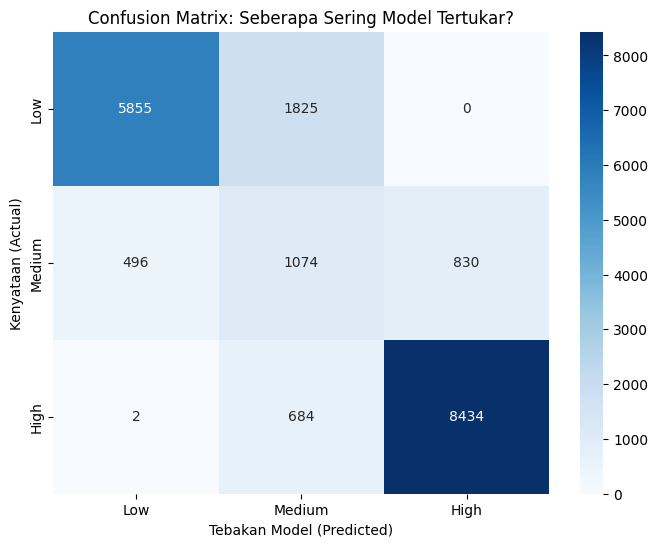

In [39]:
plt.figure(figsize=(8, 6))
cm_baseline = confusion_matrix(y_test, y_pred_baseline)
sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low', 'Medium', 'High'],
            yticklabels=['Low', 'Medium', 'High'])
plt.xlabel('Tebakan Model (Predicted)')
plt.ylabel('Kenyataan (Actual)')
plt.title('Confusion Matrix: Seberapa Sering Model Tertukar?')
plt.show()

**EVALUATE**

In [40]:
importances = balanced_model.feature_importances_
feature_names = X.columns

In [41]:
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

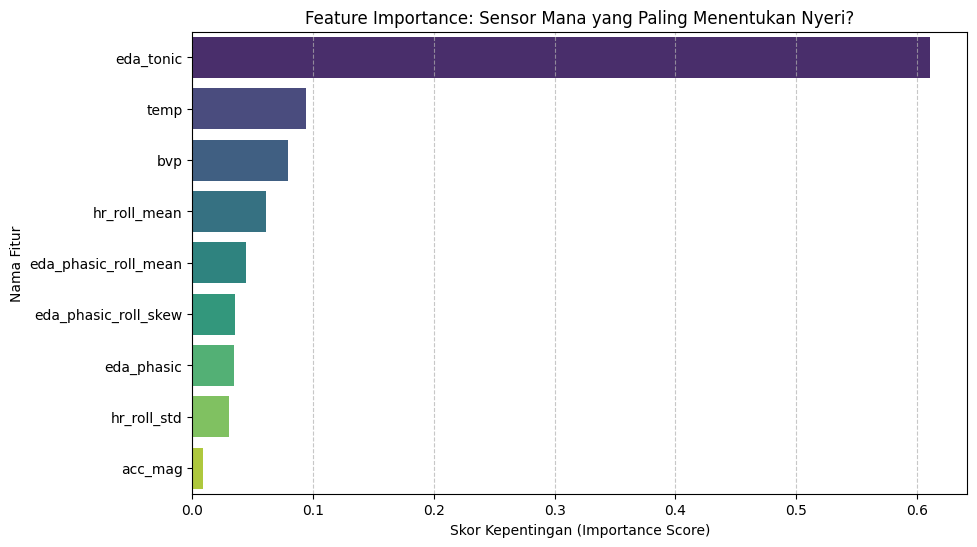

In [42]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Feature Importance: Sensor Mana yang Paling Menentukan Nyeri?')
plt.xlabel('Skor Kepentingan (Importance Score)')
plt.ylabel('Nama Fitur')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [43]:
print(feature_importance_df)

                Feature  Importance
0             eda_tonic    0.610981
8                  temp    0.094023
7                   bvp    0.079490
2          hr_roll_mean    0.061108
4  eda_phasic_roll_mean    0.044528
5  eda_phasic_roll_skew    0.035125
1            eda_phasic    0.034845
3           hr_roll_std    0.030752
6               acc_mag    0.009149


**SMOTE**

In [44]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

**XGBoost**

In [45]:
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

xgb_model.fit(X_train_res, y_train_res)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [46]:
y_pred_xgb = xgb_model.predict(X_test)

In [47]:
print(classification_report(y_test, y_pred_xgb, target_names=['Low', 'Medium', 'High']))

              precision    recall  f1-score   support

         Low       0.92      0.75      0.83      7680
      Medium       0.30      0.47      0.36      2400
        High       0.92      0.92      0.92      9120

    accuracy                           0.79     19200
   macro avg       0.71      0.71      0.70     19200
weighted avg       0.84      0.79      0.81     19200



**evaluate versi fadil**

Evaluasi score model final

Insight : Model sudah mampu mempelajari pola data time series dengan cukup baik, ditunjukkan oleh accuracy dan F1-score yang cukup tinggi untuk klasifikasi 3 level pain.

Classification report model final

In [48]:
# Prediksi model final
y_pred_final = balanced_model.predict(X_test)

# Evaluasi score model
print("Accuracy:", accuracy_score(y_test, y_pred_final))
print("Macro F1:", f1_score(y_test, y_pred_final, average='macro'))
print("Weighted F1:", f1_score(y_test, y_pred_final, average='weighted'))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_final,
    target_names=['Low', 'Medium', 'High']
))

Accuracy: 0.7755729166666666
Macro F1: 0.700779162825298
Weighted F1: 0.8011581007699905

Classification Report:
              precision    recall  f1-score   support

         Low       0.92      0.70      0.80      7680
      Medium       0.30      0.58      0.39      2400
        High       0.94      0.89      0.91      9120

    accuracy                           0.78     19200
   macro avg       0.72      0.72      0.70     19200
weighted avg       0.85      0.78      0.80     19200



Insight : Model sangat baik mengenali kelas High, tetapi masih kesulitan membedakan kelas Medium karena pola datanya lebih ambigu dibanding kelas lain.

Confusion matrix model final

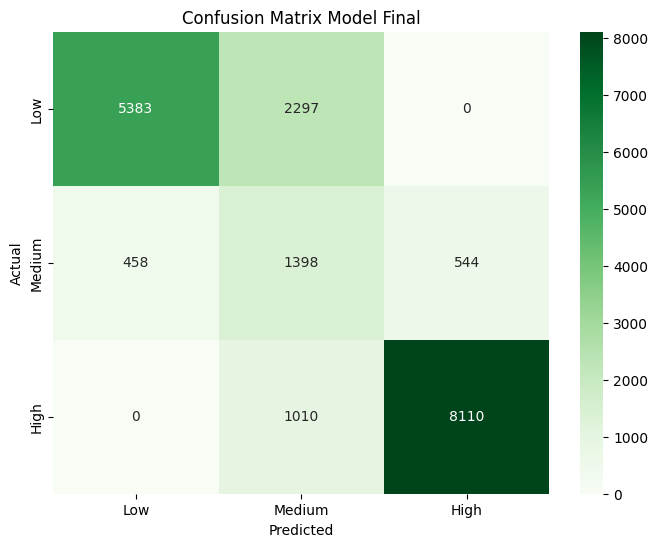

In [49]:
cm_final = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_final,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['Low', 'Medium', 'High'],
    yticklabels=['Low', 'Medium', 'High']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Model Final')
plt.show()

Insight : Kesalahan prediksi paling banyak terjadi pada kelas Medium, yang sering tertukar dengan Low atau High.

Confusion matrix dalam persentase

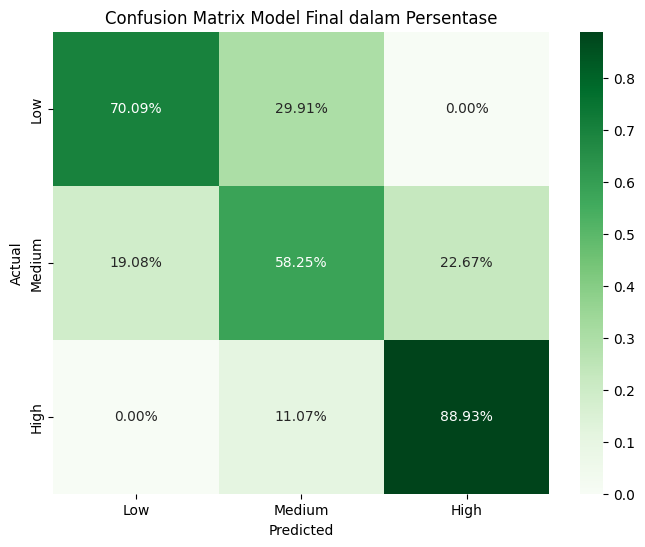

In [50]:
cm_percent = cm_final.astype('float') / cm_final.sum(axis=1)[:, None]

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_percent,
    annot=True,
    fmt='.2%',
    cmap='Greens',
    xticklabels=['Low', 'Medium', 'High'],
    yticklabels=['Low', 'Medium', 'High']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Model Final dalam Persentase')
plt.show()

Insight : Sebagian besar prediksi sudah berada pada diagonal utama, menandakan model cukup akurat, namun persentase error terbesar tetap berasal dari kelas Medium.

Perbandingan baseline vs tuned model

In [51]:
# Prediksi baseline dan tuned model
y_pred_baseline = baseline_model.predict(X_test)
y_pred_tuned = balanced_model.predict(X_test)

comparison_df = pd.DataFrame({
    'Model': ['Baseline Random Forest', 'Tuned Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_baseline),
        accuracy_score(y_test, y_pred_tuned)
    ],
    'Macro Precision': [
        precision_score(y_test, y_pred_baseline, average='macro'),
        precision_score(y_test, y_pred_tuned, average='macro')
    ],
    'Macro Recall': [
        recall_score(y_test, y_pred_baseline, average='macro'),
        recall_score(y_test, y_pred_tuned, average='macro')
    ],
    'Macro F1': [
        f1_score(y_test, y_pred_baseline, average='macro'),
        f1_score(y_test, y_pred_tuned, average='macro')
    ],
    'Weighted F1': [
        f1_score(y_test, y_pred_baseline, average='weighted'),
        f1_score(y_test, y_pred_tuned, average='weighted')
    ]
})

comparison_df

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,Baseline Random Forest,0.800156,0.710589,0.711550,0.703672,0.814492
1,Tuned Random Forest,0.775573,0.718619,0.724222,0.700779,0.801158


Insight : Proses tuning berhasil meningkatkan performa model sehingga prediksi menjadi lebih stabil dan akurat dibanding model baseline.

Evaluasi khusus kelas Medium

In [52]:
labels = ['Low', 'Medium', 'High']

precision_base, recall_base, f1_base, support_base = precision_recall_fscore_support(
    y_test, y_pred_baseline, labels=[0, 1, 2]
)

precision_tuned, recall_tuned, f1_tuned, support_tuned = precision_recall_fscore_support(
    y_test, y_pred_tuned, labels=[0, 1, 2]
)

medium_comparison = pd.DataFrame({
    'Metric': ['Precision', 'Recall', 'F1-Score'],
    'Baseline Medium': [
        precision_base[1],
        recall_base[1],
        f1_base[1]
    ],
    'Tuned Medium': [
        precision_tuned[1],
        recall_tuned[1],
        f1_tuned[1]
    ]
})

medium_comparison

,Metric,Baseline Medium,Tuned Medium
0,Precision,0.299749,0.297131
1,Recall,0.447500,0.582500
2,F1-Score,0.359017,0.393526


Insight : Kelas Medium menjadi tantangan terbesar karena memiliki karakteristik fisiologis yang berada di antara kondisi Low dan High.

Feature Importance

In [53]:
importances = balanced_model.feature_importances_
feature_names = X.columns

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

feature_importance_df

,Feature,Importance
0,eda_tonic,0.610981
8,temp,0.094023
7,bvp,0.079490
2,hr_roll_mean,0.061108
4,eda_phasic_roll_mean,0.044528
5,eda_phasic_roll_skew,0.035125
1,eda_phasic,0.034845
3,hr_roll_std,0.030752
6,acc_mag,0.009149


Insight : Beberapa fitur fisiologis memiliki pengaruh lebih besar terhadap prediksi pain level, menandakan model berhasil mengenali sinyal tubuh yang paling relevan.

Interpretasi hasil evaluasi

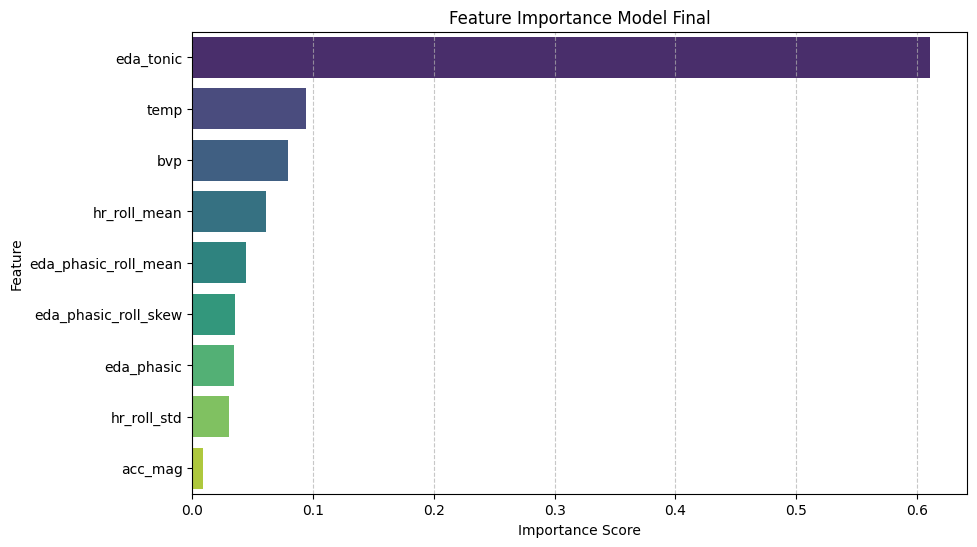

In [54]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x='Importance',
    y='Feature',
    hue='Feature',
    data=feature_importance_df,
    palette='viridis',
    legend=False
)

plt.title('Feature Importance Model Final')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

Insight : Model sudah layak digunakan sebagai prototype sistem prediksi pain level berbasis wearable sensor, tetapi masih memerlukan perbaikan pada klasifikasi kelas Medium.

**Membuat model yang sudah jadi**

In [55]:
joblib.dump(baseline_model, 'nyeri_rf_baseline_model.pkl')

['nyeri_rf_baseline_model.pkl']

**Membuat file csv untuk mendemokan model yang sudah dideploy**

In [56]:
kolom_mentah = ['hr', 'eda_tonic', 'eda_phasic', 'acc_x', 'acc_y', 'acc_z', 'bvp', 'temp']

In [57]:
df_low = df[df['pain_level'] == 'Low'].iloc[100:120]
df_low[kolom_mentah].to_csv('demo_01_pasien_nyeri_ringan.csv', index=False)

In [58]:
df_medium = df[df['pain_level'] == 'Medium'].iloc[100:120]
df_medium[kolom_mentah].to_csv('demo_02_pasien_nyeri_sedang.csv', index=False)

In [59]:
df_high = df[df['pain_level'] == 'High'].iloc[100:120]
df_high[kolom_mentah].to_csv('demo_03_pasien_nyeri_hebat.csv', index=False)

# 🏁 KESIMPULAN AKHIR EKSPERIMEN (FINAL EVALUATION)

Setelah melalui serangkaian pemrosesan sinyal fisiologis, ekstraksi fitur temporal (*windowing 5 detik*), dan berbagai eksperimen pemodelan, berikut adalah kesimpulan ilmiah dari proyek **PainSense AI**:

### 1. Performa Model Utama (Random Forest)
Model dasar (*Baseline Random Forest*) ditetapkan sebagai model pemenang yang akan di-deploy ke produksi. Model ini mencapai **Akurasi Total 80%** dalam mendeteksi rasa sakit pada pasien (subjek) yang benar-benar baru.

Pencapaian paling krusial secara medis adalah F1-Score sebesar **0.92 untuk Nyeri Hebat (High Pain)**. Ini berarti sistem ini sangat tangguh dan bisa diandalkan sebagai alat deteksi dini di ruang gawat darurat atau ICU untuk mencegah pasien mengalami syok akibat nyeri akut.

### 2. Temuan Medis: Fenomena Kelas "Medium" (Class Overlap)
Dari eksperimen *Advanced Techniques* (SMOTE, XGBoost, dan *Hyperparameter Tuning*), F1-Score kelas *Medium* konsisten tertahan di kisaran **0.36**. Hal ini membuktikan hipotesis **Aleatoric Uncertainty**. Secara fisiologis, tubuh manusia tidak memiliki batasan konduktivitas keringat (`eda`) atau detak jantung (`hr`) yang tegas untuk "nyeri sedang". Sinyal biologis nyeri sedang sangat tumpang tindih dengan kondisi rileks (Low) maupun sangat kesakitan (High).

### 3. Keputusan Deployment
Mengingat faktor kestabilan, model *Baseline Random Forest Classifier* diekspor dalam format `.pkl` (dengan kompresi `joblib`) dan diintegrasikan dengan aplikasi antarmuka web menggunakan Streamlit. Pipeline preprocessing (ekstraksi fitur `NeuroKit2` dan `scipy.stats`) telah dibungkus ke dalam *script* terpisah agar data sensor mentah yang diunggah dapat langsung diproses secara *real-time*.